# Exploratory Data Analysis (EDA) for Breast Cancer Ultrasound Dataset
This notebook performs EDA on the dataset located in the `data` directory. It includes loading images, visualizing samples, analyzing class distribution, and basic statistics.

In [1]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

In [2]:
# Set data directory and list image files
data_dir = '../data'
benign_dir = os.path.join(data_dir, 'benign')
malignant_dir = os.path.join(data_dir, 'malignant')
normal_dir = os.path.join(data_dir, 'normal')
benign_images = glob(os.path.join(benign_dir, '*'))
malignant_images = glob(os.path.join(malignant_dir, '*'))
normal_images = glob(os.path.join(normal_dir, '*'))
print(f'Benign images: {len(benign_images)}')
print(f'Malignant images: {len(malignant_images)}')
print(f'Normal images: {len(normal_images)}')

Benign images: 891
Malignant images: 421
Normal images: 266


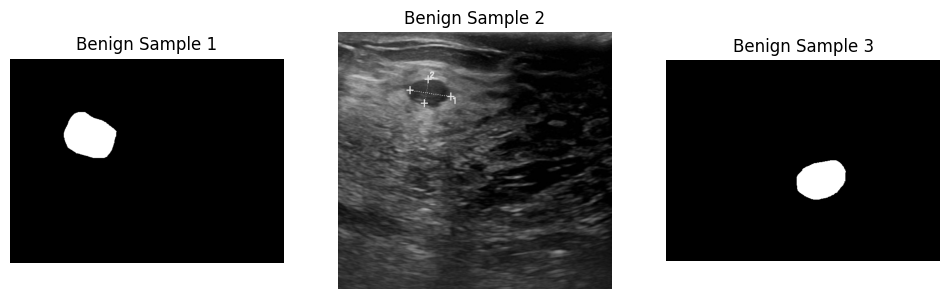

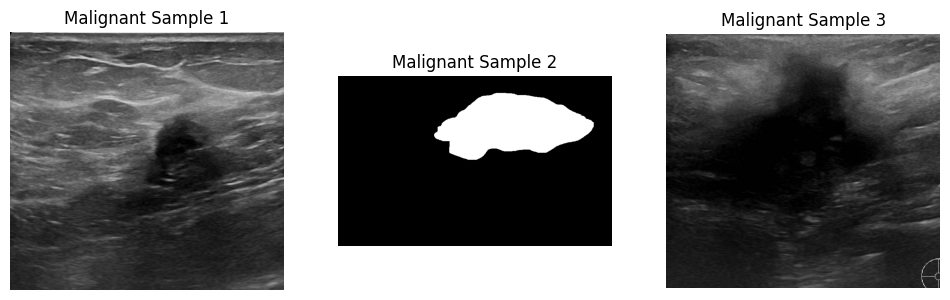

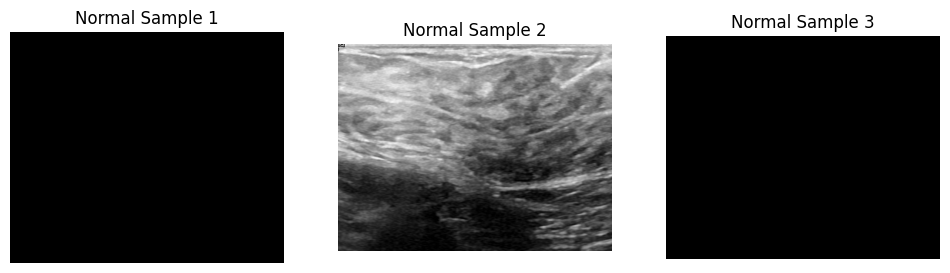

In [3]:
# Visualize sample images from each class
def show_samples(image_list, title, n=3):
    plt.figure(figsize=(12, 4))
    for i, img_path in enumerate(image_list[:n]):
        img = Image.open(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'{title} Sample {i+1}')
        plt.axis('off')
    plt.show()
show_samples(benign_images, 'Benign')
show_samples(malignant_images, 'Malignant')
show_samples(normal_images, 'Normal')

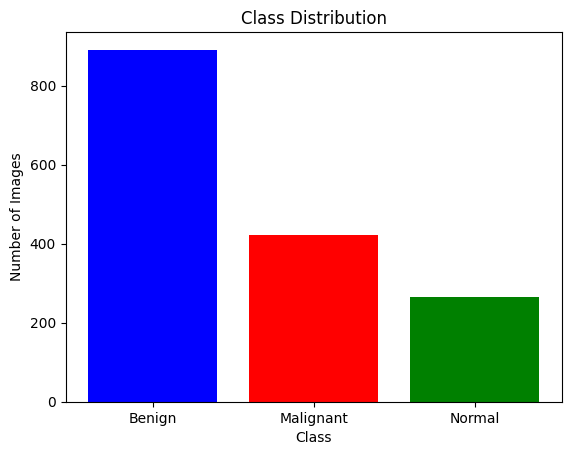

In [4]:
# Analyze class distribution
class_counts = {'Benign': len(benign_images), 'Malignant': len(malignant_images), 'Normal': len(normal_images)}
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'red', 'green'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

In [5]:
# Basic statistics: image dimensions and formats
def get_image_stats(image_list):
    dims = []
    formats = set()
    for img_path in image_list:
        img = Image.open(img_path)
        dims.append(img.size)
        formats.add(img.format)
    return dims, formats
benign_dims, benign_formats = get_image_stats(benign_images)
malignant_dims, malignant_formats = get_image_stats(malignant_images)
normal_dims, normal_formats = get_image_stats(normal_images)
print('Benign image formats:', benign_formats)
print('Malignant image formats:', malignant_formats)
print('Normal image formats:', normal_formats)
print('Benign image size stats:', np.unique(benign_dims, axis=0))
print('Malignant image size stats:', np.unique(malignant_dims, axis=0))
print('Normal image size stats:', np.unique(normal_dims, axis=0))

Benign image formats: {'PNG'}
Malignant image formats: {'PNG'}
Normal image formats: {'PNG'}
Benign image size stats: [[ 315  477]
 [ 319  473]
 [ 323  473]
 [ 349  487]
 [ 357  338]
 [ 369  342]
 [ 370  338]
 [ 378  345]
 [ 389  594]
 [ 420  474]
 [ 422  468]
 [ 433  478]
 [ 449  594]
 [ 452  591]
 [ 460  391]
 [ 462  389]
 [ 462  391]
 [ 462  404]
 [ 463  383]
 [ 463  387]
 [ 463  390]
 [ 463  392]
 [ 463  398]
 [ 465  389]
 [ 465  390]
 [ 465  395]
 [ 466  389]
 [ 466  390]
 [ 466  391]
 [ 467  387]
 [ 467  390]
 [ 467  392]
 [ 468  393]
 [ 469  386]
 [ 469  394]
 [ 469  395]
 [ 469  396]
 [ 471  386]
 [ 471  401]
 [ 472  385]
 [ 472  387]
 [ 473  389]
 [ 473  398]
 [ 498  326]
 [ 498  331]
 [ 500  327]
 [ 500  328]
 [ 501  609]
 [ 502  474]
 [ 503  328]
 [ 506  330]
 [ 510  324]
 [ 516  467]
 [ 526  331]
 [ 526  474]
 [ 544  328]
 [ 544  465]
 [ 544  468]
 [ 544  469]
 [ 546  467]
 [ 547  465]
 [ 548  464]
 [ 549  458]
 [ 549  463]
 [ 549  465]
 [ 549  467]
 [ 549  470]
 [ 549  475

In [ ]:
# DICOM image analysis: count, visualize, and stats
import pydicom
def is_dicom(path):
    return path.lower().endswith('.dcm')
dicom_images = []
for cls_dir in [benign_dir, malignant_dir, normal_dir]:
    dicom_images += [img for img in glob(os.path.join(cls_dir, '*')) if is_dicom(img)]
print(f'Total DICOM images: {len(dicom_images)}')
def show_dicom_samples(image_list, n=3):
    plt.figure(figsize=(12, 4))
    for i, img_path in enumerate(image_list[:n]):
        ds = pydicom.dcmread(img_path)
        img = ds.pixel_array
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'DICOM Sample {i+1}')
        plt.axis('off')
    plt.show()
if dicom_images:
    show_dicom_samples(dicom_images)

/home/jgibson2/projects/tas2b-net/venv/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

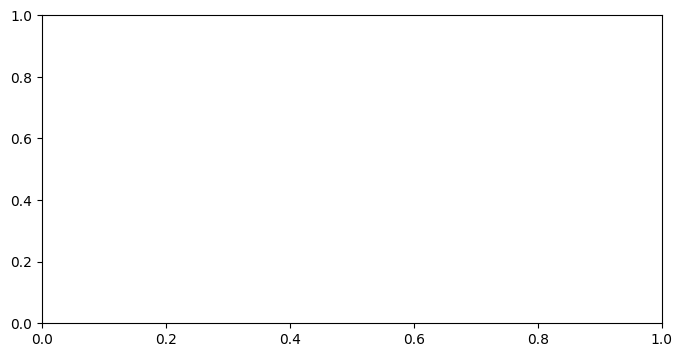

In [6]:
# Advanced analysis: pixel intensity histograms and summary stats
def plot_intensity_histogram(image_paths, title, is_dicom=False):
    plt.figure(figsize=(8, 4))
    for img_path in image_paths[:3]:
        if is_dicom:
            ds = pydicom.dcmread(img_path)
            img = ds.pixel_array
        else:
            img = np.array(Image.open(img_path))
        plt.hist(img.ravel(), bins=50, alpha=0.5, label=os.path.basename(img_path))
    plt.title(f'Pixel Intensity Histogram: {title}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
plot_intensity_histogram(benign_images, 'Benign')
plot_intensity_histogram(malignant_images, 'Malignant')
plot_intensity_histogram(normal_images, 'Normal')
if dicom_images:
    plot_intensity_histogram(dicom_images, 'DICOM', is_dicom=True)

In [ ]:
# Targeted augmentation to balance classes
from random import choice
def augment_image(img):
    # Example augmentation: horizontal flip
    return img.transpose(Image.FLIP_LEFT_RIGHT)
def balance_classes(benign_images, malignant_images, normal_images):
    max_count = max(len(benign_images), len(malignant_images), len(normal_images))
    balanced = {'Benign': list(benign_images), 'Malignant': list(malignant_images), 'Normal': list(normal_images)}
    for cls, images in balanced.items():
        while len(images) < max_count:
            img_path = choice(images)
            img = Image.open(img_path)
            aug_img = augment_image(img)
            # Save augmented image to memory (or disk if needed)
            # Here, we append to a list; for disk, save with a new filename
            images.append(img_path) # Placeholder: replace with actual augmented image path if saving to disk
        balanced[cls] = images
    return balanced
balanced = balance_classes(benign_images, malignant_images, normal_images)
print('Balanced class counts:', {cls: len(imgs) for cls, imgs in balanced.items()})